# Bab 1: Exploratory Data Analysis

**Buku:** *Practical Statistics for Data Scientists* (O'Reilly)

## Ringkasan Bab
Di bab ini buku membahas Exploratory Data Analysis (EDA), yaitu langkah awal yang sebaiknya selalu dilakukan sebelum membuat model: lihat dulu datanya. Pendekatan ini dipopulerkan oleh John Tukey. Isi bab ini kurang lebih seperti berikut.

1. **Elemen data terstruktur.** Data numerik (kontinu dan diskrit) dan data kategorikal (biner dan ordinal), serta bentuk data persegi panjang (data frame).
2. **Ukuran lokasi.** Rata-rata, rata-rata terpangkas, rata-rata berbobot, median, dan median berbobot.
3. **Ukuran variabilitas.** Varians, simpangan baku, MAD, persentil, dan IQR.
4. **Distribusi data.** Boxplot, tabel frekuensi, histogram, dan density plot.
5. **Data biner dan kategorikal.** Modus dan bar chart.
6. **Korelasi.** Koefisien korelasi, matriks korelasi, dan scatterplot.
7. **Eksplorasi dua variabel atau lebih.** Hexagonal binning, contour plot, tabel kontingensi, violin plot, dan facet.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import trim_mean
import wquantiles
import seaborn as sns
import matplotlib.pylab as plt

DATA = Path('..') / 'data'
sns.set_style('whitegrid')

## 1. Elemen Data Terstruktur
**Penjelasan teori.** Data secara umum dibagi menjadi dua jenis.
- **Numerik.** Bisa *kontinu* (nilainya bebas dalam suatu rentang, misalnya kecepatan angin) atau *diskrit* (berupa bilangan bulat hasil hitungan, misalnya jumlah kejadian).
- **Kategorikal.** Nilainya berasal dari sekumpulan kategori yang tetap. Kasus khususnya adalah *biner* (ya/tidak, 0/1) dan *ordinal* (kategori yang punya urutan, misalnya rating 1 sampai 5).

Jenis data penting untuk diketahui karena menentukan ringkasan statistik, grafik, dan model apa yang cocok dipakai. Bentuk yang paling sering ditemui adalah **data persegi panjang**, yaitu baris sebagai *record* atau kasus dan kolom sebagai *fitur* atau variabel.

## 2. Ukuran Lokasi (Estimates of Location)
**Penjelasan teori.** Ukuran lokasi menjawab pertanyaan "nilai yang paling khas dari data ini berapa?". Ukuran yang dipakai di buku:

| Ukuran | Definisi | Catatan |
|---|---|---|
| Mean | $\bar{x}=\frac{1}{n}\sum x_i$ | Mudah terpengaruh outlier |
| Trimmed mean | Mean setelah membuang sebagian nilai terkecil dan terbesar | Kompromi yang cukup tahan outlier |
| Weighted mean | $\frac{\sum w_i x_i}{\sum w_i}$ | Dipakai kalau tiap observasi punya tingkat kepentingan berbeda |
| Median | Nilai tengah (persentil ke-50) | Tahan terhadap outlier |
| Weighted median | Nilai yang membagi total bobot menjadi dua bagian sama besar | Tahan outlier dan memakai bobot |

Ukuran yang **robust** adalah ukuran yang tidak mudah berubah karena nilai ekstrem. Contoh paling jelas adalah median. Itu sebabnya data pendapatan biasanya dilaporkan dengan median, karena segelintir orang yang sangat kaya bisa membuat mean jadi terlihat jauh lebih tinggi dari kondisi kebanyakan orang.

In [2]:
state = pd.read_csv(DATA / 'state.csv')
print(state.head(8))

         State  Population  Murder.Rate Abbreviation
0      Alabama     4779736          5.7           AL
1       Alaska      710231          5.6           AK
2      Arizona     6392017          4.7           AZ
3     Arkansas     2915918          5.6           AR
4   California    37253956          4.4           CA
5     Colorado     5029196          2.8           CO
6  Connecticut     3574097          2.4           CT
7     Delaware      897934          5.8           DE


In [3]:
# Mean, trimmed mean, and median of state population
print('Mean          :', state['Population'].mean())
print('Trimmed mean  :', trim_mean(state['Population'], 0.1))
print('Median        :', state['Population'].median())

Mean          : 6162876.3
Trimmed mean  : 4783697.125
Median        : 4436369.5


Mean jauh lebih besar daripada median karena ada beberapa negara bagian dengan populasi sangat besar (misalnya California dan Texas) yang menarik mean ke atas. Ini ciri khas distribusi yang miring (skewed).

In [4]:
# Weighted mean and weighted median of murder rate, weighted by population
print('Mean murder rate          :', state['Murder.Rate'].mean())
print('Weighted mean murder rate :', np.average(state['Murder.Rate'], weights=state['Population']))
print('Weighted median           :', wquantiles.median(state['Murder.Rate'], weights=state['Population']))

Mean murder rate          : 4.066
Weighted mean murder rate : 4.445833981123393
Weighted median           : 4.4


## 3. Ukuran Variabilitas (Dispersi)
**Penjelasan teori.** Kalau ukuran lokasi memberi tahu pusat data, ukuran variabilitas memberi tahu seberapa menyebar data tersebut.

- **Deviasi** adalah selisih $x_i-\bar{x}$. Kalau dijumlahkan hasilnya selalu nol, jadi perlu dikuadratkan atau diambil nilai mutlaknya.
- **Mean absolute deviation** $=\frac{1}{n}\sum|x_i-\bar{x}|$.
- **Varians** $s^2=\frac{\sum(x_i-\bar{x})^2}{n-1}$. Pembaginya $n-1$ (derajat bebas) supaya estimasinya tidak bias.
- **Simpangan baku** $s=\sqrt{s^2}$. Satuannya sama dengan satuan data, jadi lebih mudah diinterpretasikan.
- **Median absolute deviation (MAD)** $=\text{median}(|x_i-m|)$. Ini versi yang robust.
- **Range, persentil, dan IQR.** Semuanya berbasis urutan data. $\text{IQR}=Q_3-Q_1$.

In [5]:
print('Std. deviation :', state['Population'].std())
print('IQR            :', state['Population'].quantile(0.75) - state['Population'].quantile(0.25))
# MAD (scaled to be comparable with std for normal data)
print('MAD            :', stats.median_abs_deviation(state['Population'], scale='normal'))

Std. deviation : 6848235.347401142
IQR            : 4847308.0
MAD            : 3849876.1459979336


## 4. Eksplorasi Distribusi Data
**Penjelasan teori.**
- **Persentil/kuantil** menggambarkan bentuk distribusi data.
- **Boxplot** (usulan Tukey): kotak menunjukkan $Q_1$ sampai $Q_3$, garis di dalam kotak adalah median, whisker memanjang sampai 1,5 kali IQR, dan titik di luar whisker dianggap calon outlier.
- **Tabel frekuensi dan histogram** dibuat dengan membagi data ke dalam beberapa interval (bin) lalu menghitung isinya.
- **Density plot** adalah versi histogram yang dihaluskan (kernel density estimate), diskalakan agar luas totalnya sama dengan 1.

In [6]:
print(state['Murder.Rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.95]))

0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder.Rate, dtype: float64


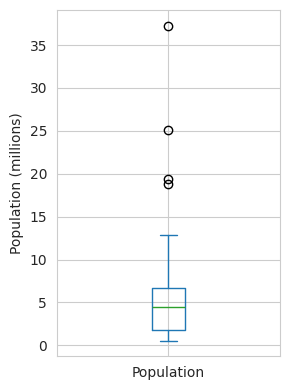

In [7]:
ax = (state['Population'] / 1_000_000).plot.box(figsize=(3, 4))
ax.set_ylabel('Population (millions)')
plt.tight_layout(); plt.show()

In [8]:
binnedPopulation = pd.cut(state['Population'], 10)
print(binnedPopulation.value_counts().sort_index())

Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
(33584923.0, 37253956.0]     1
Name: count, dtype: int64


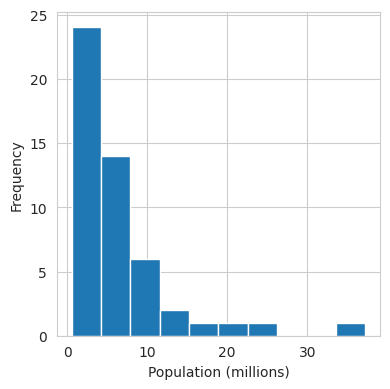

In [9]:
ax = (state['Population'] / 1_000_000).plot.hist(figsize=(4, 4))
ax.set_xlabel('Population (millions)')
plt.tight_layout(); plt.show()

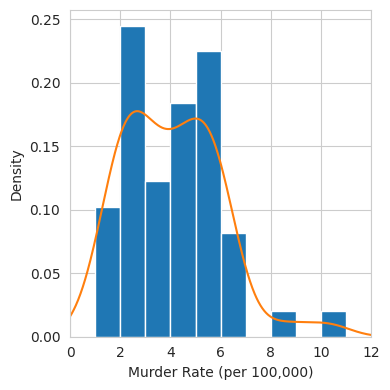

In [10]:
ax = state['Murder.Rate'].plot.hist(density=True, xlim=[0, 12], bins=range(1, 12), figsize=(4, 4))
state['Murder.Rate'].plot.density(ax=ax)
ax.set_xlabel('Murder Rate (per 100,000)')
plt.tight_layout(); plt.show()

## 5. Eksplorasi Data Biner dan Kategorikal
**Penjelasan teori.** Untuk data kategorikal, ringkasan yang dipakai adalah **proporsi**, **modus** (kategori yang paling sering muncul), dan **nilai harapan** (nilai kategori dikalikan peluangnya). Grafik yang cocok adalah **bar chart**, yang bisa dianggap sebagai padanan histogram untuk data kategorikal. Bedanya, bar chart punya jarak antar batang, sedangkan histogram tidak.

    Carrier      ATC   Weather  Security    Inbound
0  64263.16  84856.5  11235.42    343.15  118427.82


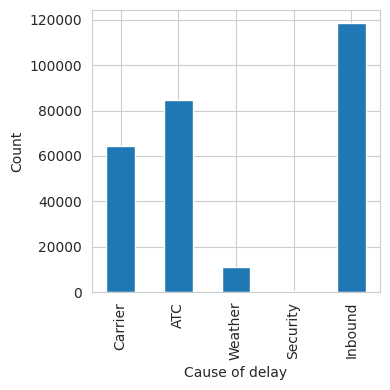

In [11]:
dfw = pd.read_csv(DATA / 'dfw_airline.csv')
print(dfw)
ax = dfw.transpose().plot.bar(figsize=(4, 4), legend=False)
ax.set_xlabel('Cause of delay'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

## 6. Korelasi
**Penjelasan teori.** **Koefisien korelasi Pearson** mengukur seberapa kuat hubungan *linear* antara dua variabel:

$$r=\frac{\sum_{i}(x_i-\bar{x})(y_i-\bar{y})}{(n-1)\,s_x s_y}$$

Nilainya ada di rentang $[-1, 1]$. Nilai +1 berarti hubungan positif sempurna, −1 berarti negatif sempurna, dan 0 berarti tidak ada hubungan linear. Korelasi Pearson sensitif terhadap outlier, jadi ada alternatif yang lebih robust yaitu korelasi peringkat Spearman dan Kendall. **Matriks korelasi** menampilkan korelasi semua pasangan variabel sekaligus. Perlu diingat bahwa korelasi tidak sama dengan sebab-akibat.

In [12]:
sp500_sym = pd.read_csv(DATA / 'sp500_sectors.csv')
sp500_px = pd.read_csv(DATA / 'sp500_data.csv.gz', index_col=0)
sp500_px.index = pd.to_datetime(sp500_px.index)

telecomSymbols = sp500_sym[sp500_sym['sector'] == 'telecommunications_services']['symbol']
telecom = sp500_px.loc[sp500_px.index >= '2012-07-01', telecomSymbols]
print(telecom.corr())

             T       CTL       FTR        VZ      LVLT
T     1.000000  0.474683  0.327767  0.677612  0.278626
CTL   0.474683  1.000000  0.419757  0.416604  0.286665
FTR   0.327767  0.419757  1.000000  0.287386  0.260068
VZ    0.677612  0.416604  0.287386  1.000000  0.242199
LVLT  0.278626  0.286665  0.260068  0.242199  1.000000


In [13]:
etfs = sp500_px.loc[sp500_px.index > '2012-07-01',
                    sp500_sym[sp500_sym['sector'] == 'etf']['symbol']]
print(etfs.head())

                 XLI       QQQ       SPY       DIA       GLD    VXX       USO  \
2012-07-02 -0.376098  0.096313  0.028223 -0.242796  0.419998 -10.40  0.000000   
2012-07-03  0.376099  0.481576  0.874936  0.728405  0.490006  -3.52  0.250000   
2012-07-05  0.150440  0.096313 -0.103487  0.149420  0.239991   6.56 -0.070000   
2012-07-06 -0.141040 -0.491201  0.018819 -0.205449 -0.519989  -8.80 -0.180000   
2012-07-09  0.244465 -0.048160 -0.056445 -0.168094  0.429992  -0.48  0.459999   

                 IWM       XLE       XLY       XLU       XLB       XTL  \
2012-07-02  0.534641  0.028186  0.095759  0.098311 -0.093713  0.019076   
2012-07-03  0.926067  0.995942  0.000000 -0.044686  0.337373  0.000000   
2012-07-05 -0.171848 -0.460387  0.306431 -0.151938  0.103086  0.019072   
2012-07-06 -0.229128  0.206706  0.153214  0.080437  0.018744 -0.429213   
2012-07-09 -0.190939 -0.234892 -0.201098 -0.035751 -0.168687  0.000000   

                 XLV       XLP       XLF       XLK  
2012-07-02 -0.0

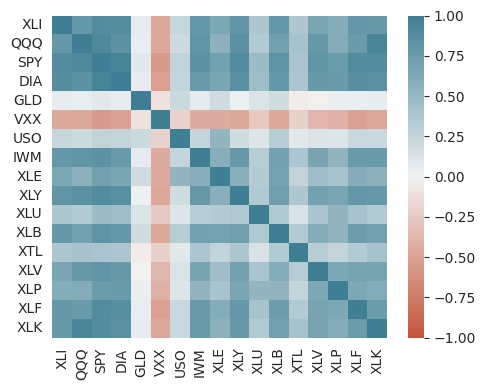

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
ax = sns.heatmap(etfs.corr(), vmin=-1, vmax=1,
                 cmap=sns.diverging_palette(20, 220, as_cmap=True), ax=ax)
plt.tight_layout(); plt.show()

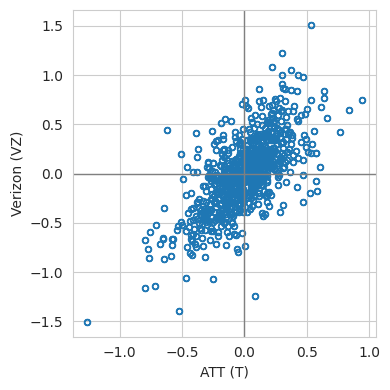

In [15]:
ax = telecom.plot.scatter(x='T', y='VZ', figsize=(4, 4), marker='$\u25EF$')
ax.set_xlabel('ATT (T)'); ax.set_ylabel('Verizon (VZ)')
ax.axhline(0, color='grey', lw=1); ax.axvline(0, color='grey', lw=1)
plt.tight_layout(); plt.show()

## 7. Eksplorasi Dua Variabel atau Lebih
**Penjelasan teori.**
- **Hexagonal binning** dan **contour plot** dipakai sebagai pengganti scatterplot ketika titiknya terlalu banyak sehingga saling menumpuk.
- **Tabel kontingensi** menghitung jumlah record untuk kombinasi dua variabel kategorikal.
- **Boxplot dan violin plot** dipakai untuk membandingkan variabel numerik antar kategori. Violin plot menampilkan bentuk distribusinya secara utuh.
- **Conditioning (facet)** mengulang grafik yang sama untuk tiap level variabel lain, sehingga kita bisa melihat banyak variabel sekaligus.

In [16]:
kc_tax = pd.read_csv(DATA / 'kc_tax.csv.gz')
kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) &
                     (kc_tax.SqFtTotLiving > 100) &
                     (kc_tax.SqFtTotLiving < 3500), :]
print(kc_tax0.shape)

(432693, 3)


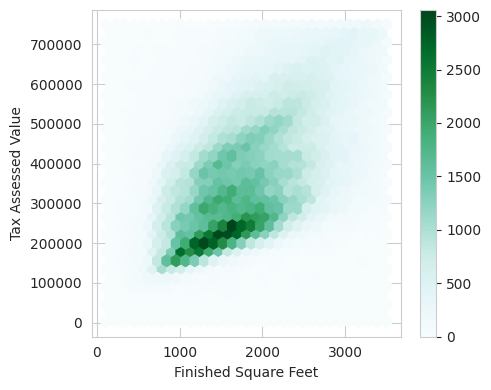

In [17]:
ax = kc_tax0.plot.hexbin(x='SqFtTotLiving', y='TaxAssessedValue',
                         gridsize=30, sharex=False, figsize=(5, 4))
ax.set_xlabel('Finished Square Feet'); ax.set_ylabel('Tax Assessed Value')
plt.tight_layout(); plt.show()

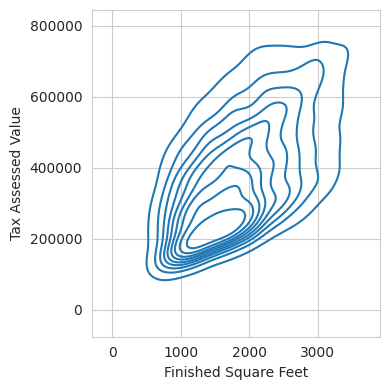

In [18]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.kdeplot(data=kc_tax0.sample(10000), x='SqFtTotLiving', y='TaxAssessedValue', ax=ax)
ax.set_xlabel('Finished Square Feet'); ax.set_ylabel('Tax Assessed Value')
plt.tight_layout(); plt.show()

In [19]:
lc_loans = pd.read_csv(DATA / 'lc_loans.csv')
crosstab = lc_loans.pivot_table(index='grade', columns='status',
                                aggfunc=lambda x: len(x), margins=True)
df = crosstab.loc['A':'G', :].astype(float).copy()
df.loc[:, 'Charged Off':'Late'] = df.loc[:, 'Charged Off':'Late'].div(df['All'], axis=0)
df['All'] = df['All'] / sum(df['All'])
perc_crosstab = df
print(crosstab)
print(perc_crosstab)

status  Charged Off  Current  Fully Paid  Late     All
grade                                                 
A              1562    50051       20408   469   72490
B              5302    93852       31160  2056  132370
C              6023    88928       23147  2777  120875
D              5007    53281       13681  2308   74277
E              2842    24639        5949  1374   34804
F              1526     8444        2328   606   12904
G               409     1990         643   199    3241
All           22671   321185       97316  9789  450961
status  Charged Off   Current  Fully Paid      Late       All
grade                                                        
A          0.021548  0.690454    0.281528  0.006470  0.160746
B          0.040054  0.709013    0.235401  0.015532  0.293529
C          0.049828  0.735702    0.191495  0.022974  0.268039
D          0.067410  0.717328    0.184189  0.031073  0.164708
E          0.081657  0.707936    0.170929  0.039478  0.077177
F          0.118

   pct_carrier_delay  pct_atc_delay  pct_weather_delay   airline
0           8.153226       1.971774           0.762097  American
1           5.959924       3.706107           1.585878  American
2           7.157270       2.706231           2.026706  American
3          12.100000      11.033333           0.000000  American
4           7.333333       3.365591           1.774194  American


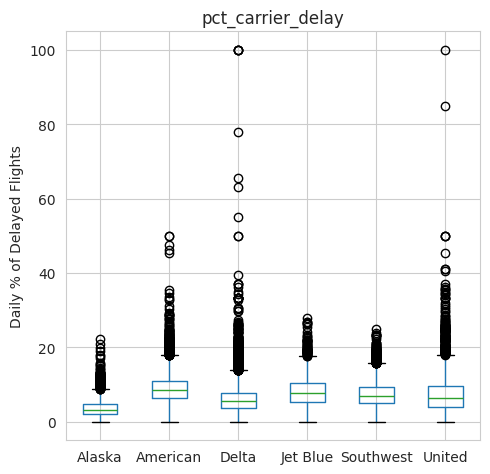

In [20]:
airline_stats = pd.read_csv(DATA / 'airline_stats.csv')
print(airline_stats.head())
ax = airline_stats.boxplot(by='airline', column='pct_carrier_delay', figsize=(5, 5))
ax.set_xlabel(''); ax.set_ylabel('Daily % of Delayed Flights')
plt.suptitle(''); plt.tight_layout(); plt.show()

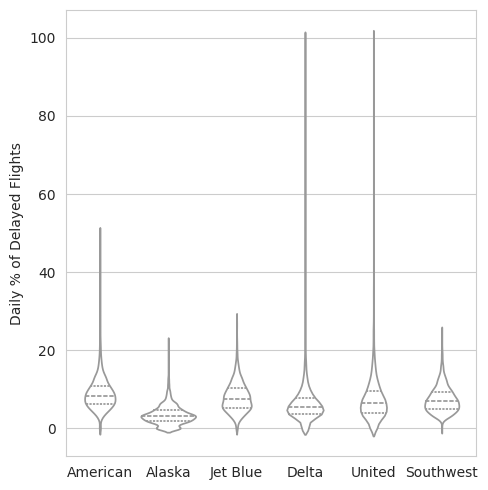

In [21]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.violinplot(data=airline_stats, x='airline', y='pct_carrier_delay',
               ax=ax, inner='quartile', color='white')
ax.set_xlabel(''); ax.set_ylabel('Daily % of Delayed Flights')
plt.tight_layout(); plt.show()

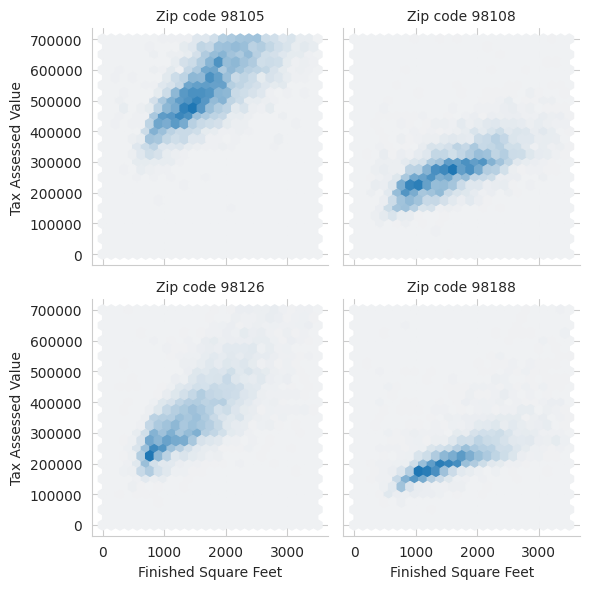

In [22]:
zip_codes = [98188, 98105, 98108, 98126]
kc_tax_zip = kc_tax0.loc[kc_tax0.ZipCode.isin(zip_codes), :]

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)

g = sns.FacetGrid(kc_tax_zip, col='ZipCode', col_wrap=2)
g.map(hexbin, 'SqFtTotLiving', 'TaxAssessedValue', extent=[0, 3500, 0, 700000])
g.set_axis_labels('Finished Square Feet', 'Tax Assessed Value')
g.set_titles('Zip code {col_name:.0f}')
plt.tight_layout(); plt.show()

## Poin Penting
- Selalu periksa data sebelum membuat model: jenis variabel, pusat, sebaran, dan bentuk distribusinya.
- Kalau data punya outlier atau miring, lebih baik pakai ukuran yang robust seperti median, trimmed mean, dan MAD.
- Pilih visualisasi sesuai ukuran data. Boxplot atau violin plot untuk perbandingan antar grup, hexbin atau contour untuk scatter yang padat.
- Korelasi hanya menangkap hubungan linear dan tidak membuktikan sebab-akibat.